# **Imports** 📓

In [1]:
import os
import sys
import shutil
import gc
import hashlib
from glob import glob
from pprint import pprint
from collections import Counter, defaultdict


import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns


from PIL import Image
import cv2
from tensorflow.keras.utils import load_img


from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG19
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping



 # **EDA** 📊

In [2]:
!pip install opendatasets

In [3]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/rahasahly/oct2017")

#Rha Sahly
#71ce9a4fe0f0ca4ac0c01ac12cbc497a
#71ce9a4fe0f0ca4ac0c01ac12cbc497a
#71ce9a4fe0f0ca4ac0c01ac12cbc497a
#71ce9a4fe0f0ca4ac0c01ac12cbc497a
#71ce9a4fe0f0ca4ac0c01ac12cbc497a

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: raneemalsulami
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rahasahly/oct2017


100%|██████████| 5.41G/5.41G [03:47<00:00, 25.5MB/s]


In [4]:

training_dir = "/content/oct2017/OCT2017/train"
testing_dir = "/content/oct2017/OCT2017/test"

**Define label mapping**

In [5]:
#mapping
label_to_class_mapping = {
    'CNV': 0,
    'DME': 1,
    'DRUSEN': 2,
    'NORMAL': 3
}


class_to_label_mapping = {v: k for k, v in label_to_class_mapping.items()}

**Load dataset**

In [6]:
                                                                                              #load dataset

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    training_dir,
    label_mode='categorical',
    labels='inferred',
    class_names=list(label_to_class_mapping.keys()),
    shuffle=True,
    seed=42
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    testing_dir,
    label_mode='categorical',
    labels='inferred',
    class_names=list(label_to_class_mapping.keys()),
    shuffle=False
)

Found 83484 files belonging to 4 classes.
Found 1000 files belonging to 4 classes.


In [7]:

train_labels = []
for _, label_batch in train_dataset:
    train_labels.extend(np.argmax(label_batch.numpy(), axis=-1))

final_test_labels = []
for _, label_batch in test_dataset:
    final_test_labels.extend(np.argmax(label_batch.numpy(), axis=-1))


In [8]:

print("Unique labels in training set:", np.unique(train_labels))
print("Unique labels in testing set:", np.unique(final_test_labels))

Unique labels in training set: [0 1 2 3]
Unique labels in testing set: [0 1 2 3]


**converting labels to integers for easier handling** + **ensure unified mapping for consistency**

In [9]:

print("Unified Label to Index Mapping:", label_to_class_mapping)
print("Unique labels in training labels:", set(train_labels))
print("Unique labels in final test labels:", set(final_test_labels))


Unified Label to Index Mapping: {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
Unique labels in training labels: {0, 1, 2, 3}
Unique labels in final test labels: {0, 1, 2, 3}


In [10]:
print("Is train_paths defined?", 'train_paths' in locals())


Is train_paths defined? False


In [11]:
image_paths = []
labels = []

for label_dir in os.listdir(training_dir):
    label_path = os.path.join(training_dir, label_dir)
    if os.path.isdir(label_path):
        for img_file in os.listdir(label_path):
            image_paths.append(os.path.join(label_path, img_file))
            labels.append(label_dir)


In [12]:
for i in range(5):
    print(f"Sample {i}: {image_paths[i]} → {labels[i]}")


Sample 0: /content/oct2017/OCT2017/train/DRUSEN/DRUSEN-8147741-3.jpeg → DRUSEN
Sample 1: /content/oct2017/OCT2017/train/DRUSEN/DRUSEN-95633-13.jpeg → DRUSEN
Sample 2: /content/oct2017/OCT2017/train/DRUSEN/DRUSEN-5801431-29.jpeg → DRUSEN
Sample 3: /content/oct2017/OCT2017/train/DRUSEN/DRUSEN-3325823-27.jpeg → DRUSEN
Sample 4: /content/oct2017/OCT2017/train/DRUSEN/DRUSEN-6193297-4.jpeg → DRUSEN


# **Detect and remove duplicates**

In [13]:

import hashlib


def compute_image_hash(image_path, chunk_size=8192):
    hasher = hashlib.md5()
    try:
        with open(image_path, 'rb') as f:
            for chunk in iter(lambda: f.read(chunk_size), b""):
                hasher.update(chunk)
    except Exception as e:
        print(f"Error reading {image_path}: {e}")
        return None
    return hasher.hexdigest()


#---------------------------------------------------------------

def remove_duplicates(image_paths, labels):
    seen_hashes = set()
    unique_image_paths = []
    unique_labels = []
    duplicates = []

    for i, image_path in enumerate(image_paths):
        image_hash = compute_image_hash(image_path)

        if image_hash is None:
            continue

        if image_hash not in seen_hashes:
            seen_hashes.add(image_hash)
            unique_image_paths.append(image_path)
            unique_labels.append(labels[i])
        else:
            duplicates.append(image_path)

    print(f"Found {len(duplicates)} duplicate images.")
    return unique_image_paths, unique_labels, duplicates

In [14]:
image_paths = []
labels = []

for label_dir in os.listdir(training_dir):
    label_path = os.path.join(training_dir, label_dir)
    if os.path.isdir(label_path):
        for img_file in os.listdir(label_path):
            image_paths.append(os.path.join(label_path, img_file))
            labels.append(label_dir)

labels = np.array([label_to_class_mapping[label] for label in labels], dtype=np.int32)


In [15]:

print("removing duplicates in the dataset")
unique_image_paths, unique_labels, duplicates = remove_duplicates(image_paths, labels)


image_paths = unique_image_paths
labels = unique_labels

assert len(image_paths) == len(labels), "Mismatch between image paths and labels after duplicate removal!"

print(f" Dataset size after duplicate removal: {len(image_paths)} images.")
print(f" Unique paths after duplicate removal: {len(set(image_paths))}")
print(f" Number of labels after duplicate removal: {len(labels)}")

if len(labels) != len(image_paths):
    print(f" Mismatch detected: {len(labels)} labels vs {len(image_paths)} image paths!")

removing duplicates in the dataset
Found 6987 duplicate images.
 Dataset size after duplicate removal: 76497 images.
 Unique paths after duplicate removal: 76497
 Number of labels after duplicate removal: 76497


In [16]:
train_labels = np.array(unique_labels, dtype=np.int32)

print(f"Final image count: {len(image_paths)}")
print(f"Final label count: {len(train_labels)}")


Final image count: 76497
Final label count: 76497


**classes distrubtion to check class imbalance**

In [17]:
train_class_counts = Counter(unique_labels)

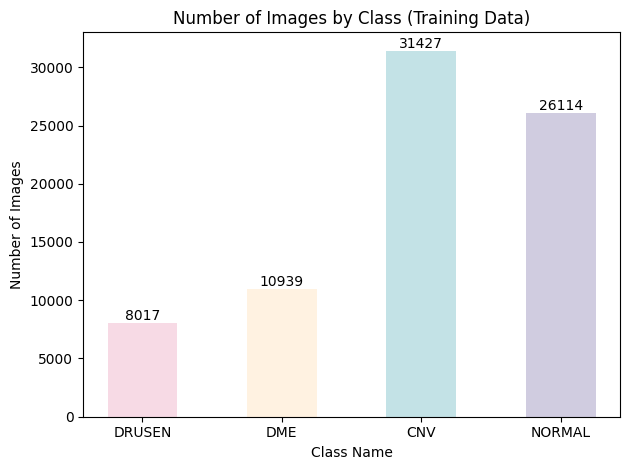

In [18]:
colors = ['#F7DAE5', '#FFF2E1', '#C3E2E6', '#D0CCE0']
train_class_counts_named = {class_to_label_mapping[key]: value for key, value in train_class_counts.items()}

plt.bar(train_class_counts_named.keys(), train_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Training Data)")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")


for i, (class_name, count) in enumerate(train_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()


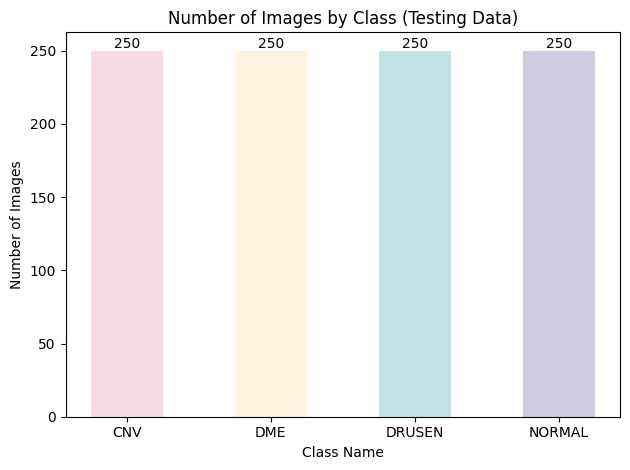

In [19]:
test_class_counts = Counter(final_test_labels)

test_class_counts_named = {class_to_label_mapping[key]: value for key, value in test_class_counts.items()}


plt.bar(test_class_counts_named.keys(), test_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Testing Data)")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")

for i, (class_name, count) in enumerate(test_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# **splitting data to 70/20/10 and combining original testing with new one**

In [20]:
import os
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from collections import Counter

In [21]:
def load_data_from_directory(directory_path):
    image_paths, labels = [], []
    for label_dir in os.listdir(directory_path):
        label_path = os.path.join(directory_path, label_dir)
        if os.path.isdir(label_path):
            for img_file in os.listdir(label_path):
                image_paths.append(os.path.join(label_path, img_file))
                labels.append(label_to_class_mapping[label_dir])
    return image_paths, labels


In [22]:

image_paths, train_labels = load_data_from_directory(training_dir)
train_labels = np.array(train_labels, dtype=np.int32)

In [23]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, train_labels, test_size=0.3, stratify=train_labels, random_state=42 #The dataset is first split into 70% training and 30% testing.
)


train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_paths, train_labels, test_size=0.2, stratify=train_labels, random_state=42 #From the 70% training set, 20% is taken as validation.
)


In [24]:

original_test_paths, original_test_labels = load_data_from_directory(testing_dir)
original_test_labels = np.array(original_test_labels, dtype=np.int32)


final_test_paths = np.concatenate([test_paths, original_test_paths])
final_test_labels = np.concatenate([test_labels, original_test_labels])


unique_classes, class_counts = np.unique(final_test_labels, return_counts=True)
min_samples_per_class = min(class_counts)


In [25]:
balanced_test_paths = []
balanced_test_labels = []


In [26]:
for class_label in unique_classes:
    class_indices = np.where(final_test_labels == class_label)[0]
    selected_indices = np.random.choice(class_indices, min_samples_per_class, replace=False)
    balanced_test_paths.extend(final_test_paths[selected_indices])
    balanced_test_labels.extend(final_test_labels[selected_indices])



In [27]:

balanced_test_paths = np.array(balanced_test_paths)
balanced_test_labels = np.array(balanced_test_labels)



In [28]:
print(f" Training paths: {len(train_paths)}")
print(f" Validation paths: {len(val_paths)}")
print(f" Testing paths (balanced): {len(balanced_test_paths)}")

print(" Training class distribution:", Counter(train_labels))
print(" Validation class distribution:", Counter(val_labels))
print(" Testing class distribution (balanced):", Counter(balanced_test_labels))


 Training paths: 46750
 Validation paths: 11688
 Testing paths (balanced): 11340
 Training class distribution: Counter({0: 20834, 3: 14736, 1: 6355, 2: 4825})
 Validation class distribution: Counter({0: 5209, 3: 3684, 1: 1589, 2: 1206})
 Testing class distribution (balanced): Counter({0: 2835, 1: 2835, 2: 2835, 3: 2835})


In [29]:
train_labels = np.array(train_labels, dtype=np.int32)
val_labels = np.array(val_labels, dtype=np.int32)
balanced_test_labels = np.array(balanced_test_labels, dtype=np.int32)

train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
val_dataset = tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((balanced_test_paths, balanced_test_labels))


In [30]:
print(f" Training dataset: {len(list(train_dataset))} samples")
print(f" Validation dataset: {len(list(val_dataset))} samples")
print(f" Testing dataset (balanced): {len(list(test_dataset))} samples")

 Training dataset: 46750 samples
 Validation dataset: 11688 samples
 Testing dataset (balanced): 11340 samples


# **classes distrubtion**

In [31]:
index_to_label = {0: 'CNV', 1: 'DME', 2: 'DRUSEN', 3: 'NORMAL'}


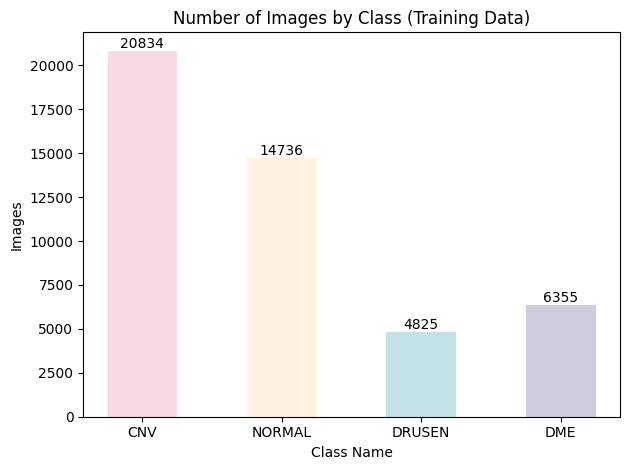

In [32]:
                                                              #training data distribution

train_class_counts = Counter(train_labels)
train_class_counts_named = {index_to_label[key]: value for key, value in train_class_counts.items()}

colors = ['#F7DAE5', '#FFF2E1', '#C3E2E6', '#D0CCE0']
plt.bar(train_class_counts_named.keys(), train_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Training Data)")
plt.xlabel("Class Name")
plt.ylabel("Images")
for i, (class_name, count) in enumerate(train_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')
plt.tight_layout()
plt.show()

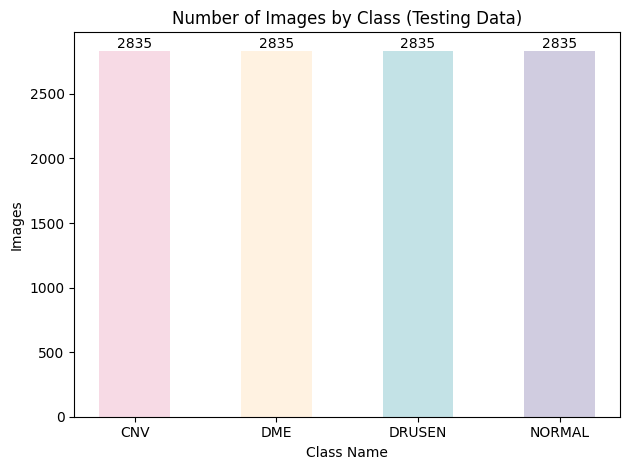

In [33]:
test_class_counts = Counter(balanced_test_labels)
test_class_counts_named = {index_to_label[key]: value for key, value in test_class_counts.items()}

plt.bar(test_class_counts_named.keys(), test_class_counts_named.values(), color=colors, width=0.5)

plt.title("Number of Images by Class (Testing Data)")
plt.xlabel("Class Name")
plt.ylabel("Images")

for i, (class_name, count) in enumerate(test_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()




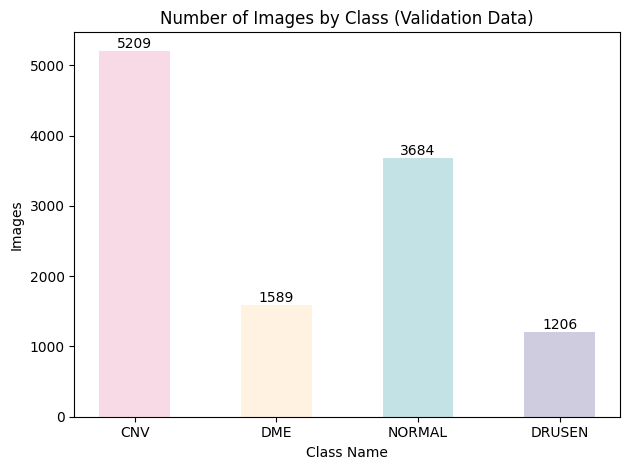

In [34]:
val_class_counts = Counter(val_labels)
val_class_counts_named = {index_to_label[key]: value for key, value in val_class_counts.items()}


plt.bar(val_class_counts_named.keys(), val_class_counts_named.values(), color=colors, width=0.5)
plt.title("Number of Images by Class (Validation Data)")
plt.xlabel("Class Name")
plt.ylabel("Images")


for i, (class_name, count) in enumerate(val_class_counts_named.items()):
    plt.text(i, count, str(count), color='black', ha='center', va='bottom')

plt.tight_layout()
plt.show()


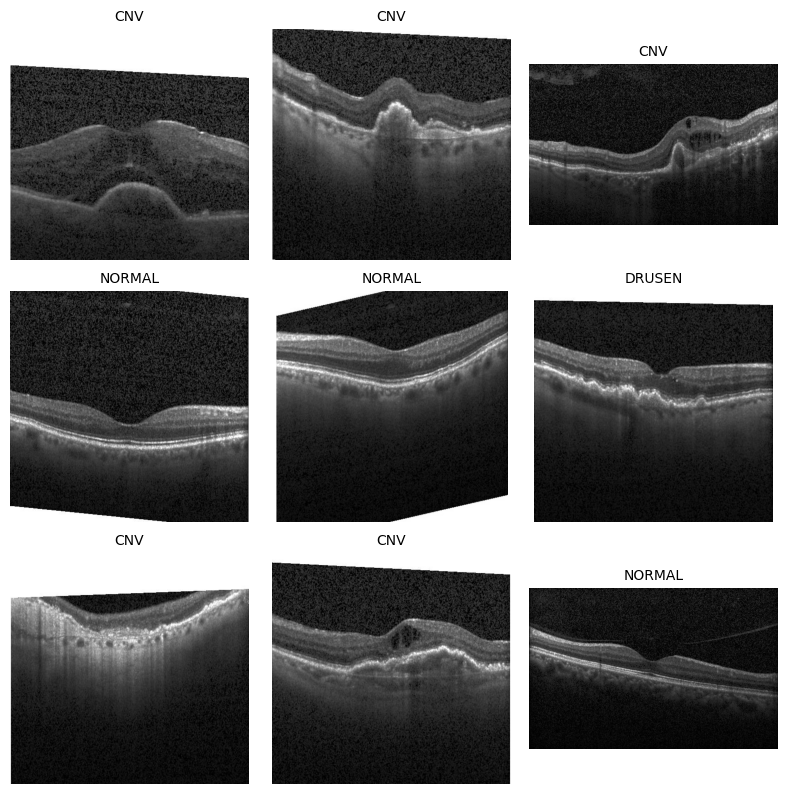

In [35]:
from tensorflow.keras.utils import load_img

fig, axes = plt.subplots(3, 3, figsize=(8, 8), facecolor="white")
axes = axes.flatten()

for i, (image_path, label) in enumerate(train_dataset.take(9)):
    img = load_img(image_path.numpy().decode('utf-8'))
    axes[i].imshow(img, cmap="gray")
    class_name = index_to_label[int(label.numpy())]
    axes[i].set_title(f"{class_name}", fontsize=10, color="black")
    axes[i].axis("off")

plt.tight_layout(pad=1.0)
plt.show()


In [36]:
print("Label Mapping:", label_to_class_mapping)
print("Unique labels in train set:", set(train_labels))
print("Unique labels in validation set:", set(val_labels))
print("Unique labels in test set:", set(final_test_labels))


Label Mapping: {'CNV': 0, 'DME': 1, 'DRUSEN': 2, 'NORMAL': 3}
Unique labels in train set: {0, 1, 2, 3}
Unique labels in validation set: {0, 1, 2, 3}
Unique labels in test set: {0, 1, 2, 3}


In [37]:

print(f"New test split count: {len(test_paths)}")
print(f"Original test set count: {len(original_test_paths)}")
print(f"Total combined test count (before balancing): {len(final_test_paths)}")


print(f"Balanced test set count: {len(balanced_test_paths)}")


New test split count: 25046
Original test set count: 1000
Total combined test count (before balancing): 26046
Balanced test set count: 11340


In [38]:
print("Final Balanced Test Class Distribution:", Counter(balanced_test_labels))


Final Balanced Test Class Distribution: Counter({0: 2835, 1: 2835, 2: 2835, 3: 2835})


In [39]:
assert len(train_paths) == len(train_labels), "Mismatch in training data!"
assert len(val_paths) == len(val_labels), "Mismatch in validation data!"
assert len(balanced_test_paths) == len(balanced_test_labels), "Mismatch in test data!"

print(f" Training samples: {len(train_paths)}")
print(f" Validation samples: {len(val_paths)}")
print(f" Testing samples (balanced): {len(balanced_test_paths)}")



 Training samples: 46750
 Validation samples: 11688
 Testing samples (balanced): 11340


# **Preproccesing**

In [40]:
def refine_cropping(image):
    image = tf.cast(image, tf.float32)
    histogram = tf.histogram_fixed_width(image, [0, 255], nbins=256)

    peak_intensity = tf.argmax(histogram[-50:]) + 175
    threshold = tf.cast(peak_intensity - 10, tf.float32)

    binary_mask = tf.where(image >= threshold, 255.0, 0.0)

    non_white_coords = tf.where(binary_mask < 255.0)

    ymin = tf.cast(tf.reduce_min(non_white_coords[:, 0]), tf.int32)
    ymax = tf.cast(tf.reduce_max(non_white_coords[:, 0]), tf.int32)
    xmin = tf.cast(tf.reduce_min(non_white_coords[:, 1]), tf.int32)
    xmax = tf.cast(tf.reduce_max(non_white_coords[:, 1]), tf.int32)

    image_shape = tf.shape(image)
    margin = tf.minimum(tf.constant(20, dtype=tf.int32), tf.minimum(ymin, xmin))

    ymin = tf.maximum(0, ymin - margin)
    ymax = tf.minimum(image_shape[0], ymax + margin)
    xmin = tf.maximum(0, xmin - margin)
    xmax = tf.minimum(image_shape[1], xmax + margin)

    cropped_image = tf.image.crop_to_bounding_box(
        tf.cast(image, tf.uint8), ymin, xmin, ymax - ymin, xmax - xmin
    )

    return cropped_image


In [41]:
def preprocess_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=1)

    cropped_image = refine_cropping(image)

    contrast_adjusted = tf.image.adjust_contrast(cropped_image, contrast_factor=2.0)
    contrast_adjusted = tf.image.adjust_contrast(contrast_adjusted, contrast_factor=1.5)

    resized_image = tf.image.resize(contrast_adjusted, [224, 224], method=tf.image.ResizeMethod.BICUBIC)

    normalized_image = resized_image / 255.0

    rgb_image = tf.image.grayscale_to_rgb(normalized_image)

    return rgb_image, label

In [42]:
                                                                              #augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.01),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.1),
])

In [43]:
def augment_image(image, label):
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = data_augmentation(image)
    return image, label


In [44]:
train_dataset_processed = train_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset_processed = val_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset_processed = test_dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)


In [45]:
train_dataset_augmented = train_dataset_processed.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)


In [46]:
train_dataset_augmented = train_dataset_augmented.batch(16).prefetch(tf.data.AUTOTUNE)
val_dataset_processed = val_dataset_processed.batch(16).prefetch(tf.data.AUTOTUNE)
test_dataset_processed = test_dataset_processed.batch(16).prefetch(tf.data.AUTOTUNE)

In [47]:

for img_batch, lbl_batch in train_dataset_augmented.take(1):
    print(f"Batch shape: {img_batch.shape}")
    print(f"Label batch shape: {lbl_batch.shape}")


Batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


In [48]:
for img_batch, lbl_batch in train_dataset_augmented.take(1):
    print(f"Batch shape: {img_batch.shape}")
    print(f"Label batch shape: {lbl_batch.shape}")


Batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


In [49]:

def count_samples(dataset):
    return sum(1 for _ in dataset)

train_count = count_samples(train_dataset_augmented) * 16
val_count = count_samples(val_dataset_processed) * 16
test_count = count_samples(test_dataset_processed) * 16

print(f"Total Training Samples: {train_count}")
print(f"Total Validation Samples: {val_count}")
print(f"Total Testing Samples: {test_count}")


Total Training Samples: 46752
Total Validation Samples: 11696
Total Testing Samples: 11344


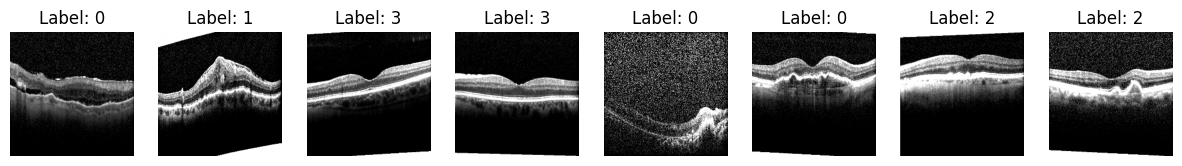

In [50]:
N = 7
for i, (img_batch, lbl_batch) in enumerate(train_dataset_processed.batch(8)):
    if i < N:
        continue
    img_batch = img_batch.numpy()
    lbl_batch = lbl_batch.numpy()
    break

fig, axes = plt.subplots(1, 8, figsize=(15, 5))
for i in range(8):
    img = np.clip(img_batch[i], 0, 1)
    axes[i].imshow(img)
    axes[i].set_title(f"Label: {lbl_batch[i]}")
    axes[i].axis("off")

plt.show()



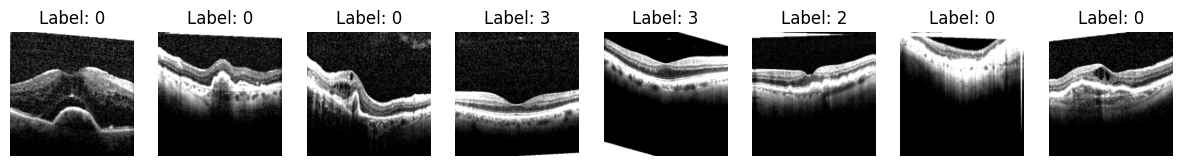

In [51]:

for img_batch, lbl_batch in train_dataset_augmented.take(1):
    img_batch = img_batch.numpy()
    lbl_batch = lbl_batch.numpy()

    num_images = min(8, img_batch.shape[0])

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        img = np.clip(img_batch[i], 0, 1)
        axes[i].imshow(img)
        axes[i].set_title(f"Label: {lbl_batch[i]}")
        axes[i].axis("off")

    plt.show()


# Data augmenation

In [52]:
from sklearn.utils.class_weight import compute_class_weight

unique_classes = np.unique(train_labels)


class_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=train_labels
)


class_weight_dict = {
    class_idx: weight for class_idx, weight in zip(unique_classes, class_weights)
}

print("Class weights:", class_weight_dict)


Class weights: {0: 0.5609820485744457, 1: 1.8391030684500393, 2: 2.422279792746114, 3: 0.7931256786102063}


In [53]:
class_weight_dict2 = {
    0: 0.6,
    1: 1.8,
    2: 3.0,
    3: 0.7
}


In [54]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import CosineDecay
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

In [73]:

# Load the base model (pretrained on ImageNet)
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze the base model initially

# Build the model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1024, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005)),  # Reduce L2 Regularization
    layers.Dropout(0.4),  # Reduce Dropout
    layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0005)),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])

# Unfreeze more layers for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-25]:  # Keep only first 25 layers frozen
    layer.trainable = False

# Compile the model with a slightly higher learning rate for better fine-tuning
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


class_weight_dict = {class_idx: weight for class_idx, weight in zip(unique_classes, class_weights)}


data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,  # Allow more patience for better fine-tuning
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # Reduce LR by 50% when no improvement
    patience=2,
    min_lr=1e-6
)

# Train the model
history_fine_tune = model.fit(
    train_dataset_augmented.map(lambda x, y: (data_augmentation(x), y)),  # Apply augmentation
    validation_data=val_dataset_processed,
    epochs=25,  # Increase training epochs
    class_weight=class_weight_dict,
    callbacks=[early_stopping, reduce_lr]  # Use both EarlyStopping & LR Scheduler
)


Epoch 1/25
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 607s 203ms/step - accuracy: 0.7045 - loss: 1.6778 - val_accuracy: 0.7904 - val_loss: 1.3413 - learning_rate: 5.0000e-05
Epoch 2/25
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 583s 200ms/step - accuracy: 0.8428 - loss: 1.2280 - val_accuracy: 0.8304 - val_loss: 1.0771 - learning_rate: 5.0000e-05
Epoch 3/25
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 582s 199ms/step - accuracy: 0.8615 - loss: 1.0054 - val_accuracy: 0.8659 - val_loss: 0.8232 - learning_rate: 5.0000e-05
Epoch 4/25
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 588s 201ms/step - accuracy: 0.8765 - loss: 0.8151 - val_accuracy: 0.8564 - val_loss: 0.7151 - learning_rate: 5.0000e-05
Epoch 5/25
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 586s 200ms/step - accuracy: 0.8793 - loss: 0.6768 - val_accuracy: 0.8687 - val_loss: 0.5931 - learning_rate: 5.0000e-05
Epoch 6/25
2922/2922 ━━━━━━━━━━━━━━━━━━━━ 596s 204ms/step - accuracy: 0.8845 - loss: 0.5778 - val_accuracy: 0.8336 - val_loss: 0.6182 - learning_rate: 5.0000e-05
Epoch 7/25
2922/2922 ━━━━━━━

In [75]:
print(len(base_model.layers))

154


In [74]:
print("Final Training Accuracy: {:.4f}".format(history_fine_tune.history['accuracy'][-1]))
print("Final Validation Accuracy: {:.4f}".format(history_fine_tune.history['val_accuracy'][-1]))


Final Training Accuracy: 0.9302
Final Validation Accuracy: 0.8907


In [76]:
test_loss, test_accuracy = model.evaluate(test_dataset_processed)
print(f"Test Accuracy: {test_accuracy}")

709/709 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.8855 - loss: 0.3525
Test Accuracy: 0.8925926089286804


In [77]:
val_loss, val_accuracy = model.evaluate(val_dataset_processed)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

731/731 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.9009 - loss: 0.3170
Validation Loss: 0.3266
Validation Accuracy: 0.8973


**model performance visulization**

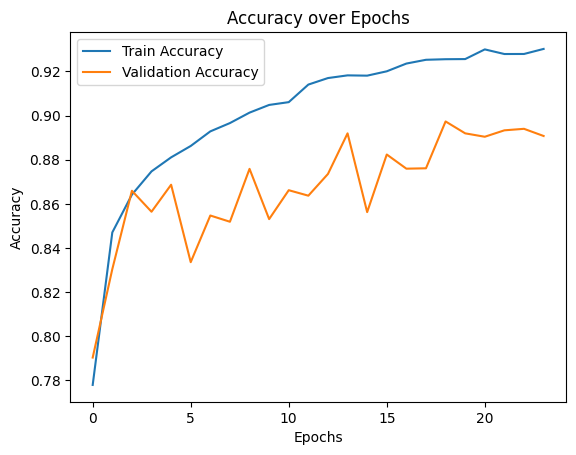

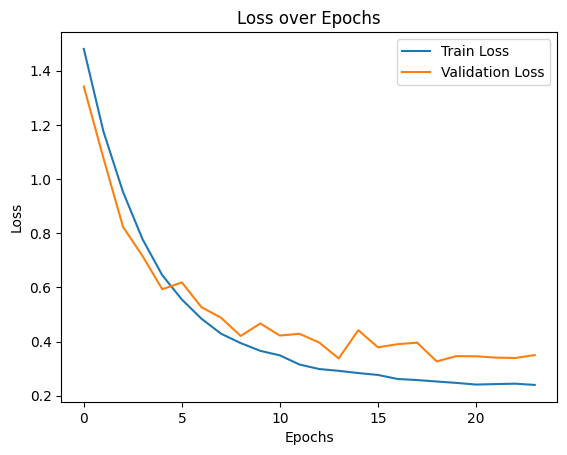

In [78]:
plt.plot(history_fine_tune.history['accuracy'], label='Train Accuracy') # Use history_fine_tune instead of history
plt.plot(history_fine_tune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_fine_tune.history['loss'], label='Train Loss') # Use history_fine_tune instead of history
plt.plot(history_fine_tune.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

[[2447  146  237    5]
 [  23 2697   17   98]
 [ 135   96 2337  267]
 [   2  111   81 2641]]


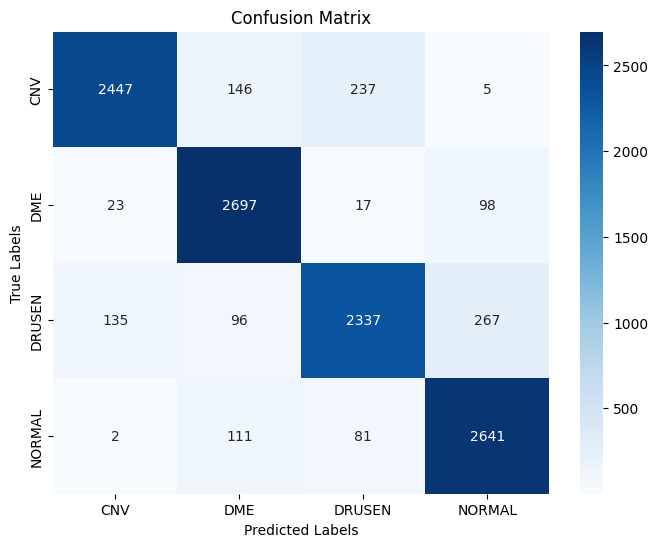

In [79]:
y_true = []
y_pred = []

for images, labels in test_dataset_processed:
    y_true.extend(labels.numpy())
    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))



cm = confusion_matrix(y_true, y_pred)
print(cm)




class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)


plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()



In [80]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(f"Confusion Matrix:\n{cm}")
print(f"Total samples in confusion matrix: {cm.sum()}")


Confusion Matrix:
[[2447  146  237    5]
 [  23 2697   17   98]
 [ 135   96 2337  267]
 [   2  111   81 2641]]
Total samples in confusion matrix: 11340


In [81]:
print(f"Data type of y_true: {type(y_true[0])}")
print(f"Data type of y_pred: {type(y_pred[0])}")


Data type of y_true: <class 'numpy.int32'>
Data type of y_pred: <class 'numpy.int64'>


In [82]:
y_true = [int(label) for label in y_true]
y_pred = [int(label) for label in y_pred]


In [83]:

true_counts = Counter(y_true)
pred_counts = Counter(y_pred)

print(f"True label counts: {true_counts}")
print(f"Predicted label counts: {pred_counts}")


True label counts: Counter({0: 2835, 1: 2835, 2: 2835, 3: 2835})
Predicted label counts: Counter({1: 3050, 3: 3011, 2: 2672, 0: 2607})


In [84]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["CNV", "DME", "DRUSEN", "NORMAL"]))



              precision    recall  f1-score   support

         CNV       0.94      0.86      0.90      2835
         DME       0.88      0.95      0.92      2835
      DRUSEN       0.87      0.82      0.85      2835
      NORMAL       0.88      0.93      0.90      2835

    accuracy                           0.89     11340
   macro avg       0.89      0.89      0.89     11340
weighted avg       0.89      0.89      0.89     11340



Predictions shape: (11340, 4)
ROC-AUC Scores:
CNV: 0.9868
DME: 0.9891
DRUSEN: 0.9694
NORMAL: 0.9875


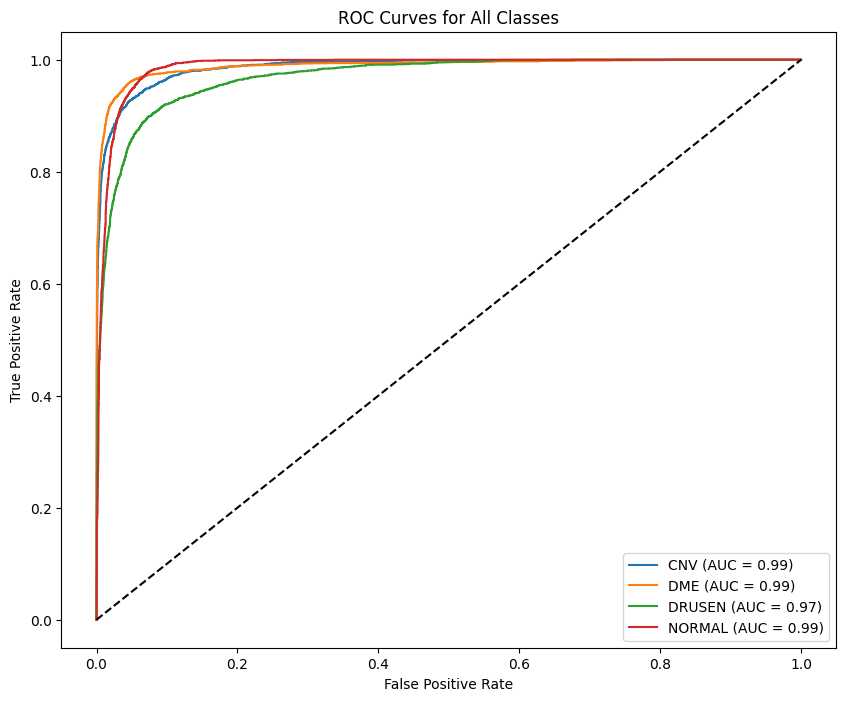

In [85]:

from sklearn.metrics import roc_auc_score, roc_curve

class_labels =  ["CNV", "DME", "DRUSEN", "NORMAL"]



predictions = model.predict(test_dataset_processed, verbose=0)
print(f"Predictions shape: {predictions.shape}")

true_labels_one_hot = np.zeros((len(y_true), len(class_labels)))
true_labels_one_hot[np.arange(len(y_true)), y_true] = 1

roc_auc_scores = {}
for i, class_name in enumerate(class_labels):
    roc_auc_scores[class_name] = roc_auc_score(true_labels_one_hot[:, i], predictions[:, i])

print("ROC-AUC Scores:")
for class_name, score in roc_auc_scores.items():
    print(f"{class_name}: {score:.4f}")

plt.figure(figsize=(10, 8))
for i, class_name in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(true_labels_one_hot[:, i], predictions[:, i])
    plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc_scores[class_name]:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curves for All Classes')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()



In [86]:
print(model.summary())


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1024)                │       1,311,744 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,497,614 (40.05 MB)

 Trainable params: 3,200,516 (12.21 MB)

 Non-trainable params: 896,064 (3.42 MB)

 Optimizer params: 6,401,034 (24.42 MB)

None


In [71]:
model.save('ttry2.h5')
print("Model saved successfully!")

Model saved successfully!
